<a href="https://colab.research.google.com/github/juheesun/-/blob/main/%EC%B6%94%EC%8B%9C1_%ED%95%99%EC%8A%B5_%EA%B3%B5%EC%9C%A01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import precision_score, recall_score, f1_score

## 데이터로드

In [2]:
# 1. 드라이브 마운트
drive.mount('/content/drive')

# 2. 경로 설정
base_path = '/content/drive/MyDrive/Recommender_systems/ml-100k/'

# 3. 데이터 로드
df = pd.read_csv(base_path + 'ua.base', sep='\t', names=['user_id', 'movie_id', 'rating', 'timestamp'])

# 4. 데이터 분리 (오류 났던 부분 수정: ratings -> df)
# 랜덤 분리
train_random, val_random = train_test_split(df, test_size=0.2, random_state=42)

# 시간순 분리
df_sorted = df.sort_values(['user_id', 'timestamp'])
val_time = df_sorted.groupby('user_id').tail(5)
train_time = df_sorted.drop(val_time.index)

print("데이터 준비 완료!")
print(f"Random Split - 학습: {len(train_random)}, 검증: {len(val_random)}")
print(f"Time Split   - 학습: {len(train_time)}, 검증: {len(val_time)}")

Mounted at /content/drive
데이터 준비 완료!
Random Split - 학습: 72456, 검증: 18114
Time Split   - 학습: 85855, 검증: 4715


# 사용자 기반

## 행렬 + KNN

In [3]:
class DampedKNNRecommender:
    def __init__(self, k=20, damping_factor=10):
        self.k = k
        self.damping = damping_factor
        self.mu = 0
        self.bu = None
        self.bi = None
        self.sim_matrix = None
        self.res_matrix = None # 잔차 행렬 (R - Baseline)

    def fit(self, train_df):
        # 1. 전체 평균
        self.mu = train_df['rating'].mean()

        # 2. Damped Item Bias (bi)
        item_group = train_df.groupby('movie_id')['rating']
        self.bi = (item_group.sum() - item_group.count() * self.mu) / (item_group.count() + self.damping)

        # 3. Damped User Bias (bu)
        # 아이템 편향을 먼저 제거한 후 유저 편향 계산
        train_df = train_df.copy()
        train_df['temp'] = train_df.apply(lambda x: x['rating'] - self.mu - self.bi.get(x['movie_id'], 0), axis=1)
        user_group = train_df.groupby('user_id')['temp']
        self.bu = user_group.sum() / (user_group.count() + self.damping)

        # 4. 잔차 행렬 생성 (결측치는 0처리)
        # Baseline = mu + bu + bi
        train_df['res'] = train_df.apply(lambda x: x['rating'] - (self.mu + self.bu.get(x['user_id'], 0) + self.bi.get(x['movie_id'], 0)), axis=1)
        self.res_matrix = train_df.pivot(index='user_id', columns='movie_id', values='res').fillna(0)

        # 5. 사용자 간 유사도 계산 (잔차 기반 코사인 유사도)
        self.sim_matrix = pd.DataFrame(cosine_similarity(self.res_matrix),
                                      index=self.res_matrix.index, columns=self.res_matrix.index)

    def predict(self, u_id, m_id):
        # 예측의 기본값은 Baseline
        bu = self.bu.get(u_id, 0)
        bi = self.bi.get(m_id, 0)
        baseline = self.mu + bu + bi

        # 학습 데이터에 유저나 영화가 없는 경우 Baseline 반환
        if u_id not in self.sim_matrix.index or m_id not in self.res_matrix.columns:
            return baseline

        # 해당 영화(m_id)를 평가한 다른 유저들의 잔차 가져오기
        movie_res = self.res_matrix.loc[:, m_id]
        similar_users = movie_res[movie_res != 0].index

        # 유사도 높은 순으로 K명 추출
        sim_scores = self.sim_matrix.loc[u_id, similar_users].sort_values(ascending=False)[:self.k]

        if sim_scores.sum() <= 0:
            return baseline

        # 예측값 = Baseline + (유사도 가중 평균된 잔차)
        res_pred = np.dot(sim_scores, movie_res[sim_scores.index]) / np.abs(sim_scores).sum()
        return baseline + res_pred

## 평가

In [4]:
k_candidates = [10, 20, 30, 40, 50]
user_based_results = {}

for name, train_set, val_set in [("Random Split", train_random, val_random), ("Time Split", train_time, val_time)]:
    print(f"\n[{name}] 사용자 기반 실험 시작...")
    best_rmse = float('inf')

    for k in k_candidates:
        model = DampedKNNRecommender(k=k, damping_factor=10)
        model.fit(train_set)

        # 검증셋 예측
        preds = val_set.apply(lambda x: model.predict(x['user_id'], x['movie_id']), axis=1)
        preds = np.array(preds)
        actual = val_set['rating'].values

        # 1. 오차 지표 계산
        rmse = np.sqrt(mean_squared_error(actual, preds))
        mae = mean_absolute_error(actual, preds)

        # 2. 랭킹 지표 계산 (4.0점 이상 선호 기준)
        threshold = 4.0
        actual_rel = actual >= threshold
        pred_rel = preds >= threshold

        tp = np.sum(actual_rel & pred_rel)
        precision = tp / np.sum(pred_rel) if np.sum(pred_rel) > 0 else 0
        recall = tp / np.sum(actual_rel) if np.sum(actual_rel) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        print(f"K={k} -> RMSE: {rmse:.4f}, F1: {f1:.4f}")

        # 가장 성능이 좋은(RMSE 기준) 결과를 저장
        if rmse < best_rmse:
            best_rmse = rmse
            user_based_results[name] = {
                    'K': k,
                    'RMSE': rmse,
                    'MAE': mae,
                    'Precision': precision,
                    'Recall': recall,
                    'F1': f1
                }

# 최종 결과 요약 출력 (표 형태)
print("\n" + "="*80)
print(f"{'검증 방식':<15} | {'Best K':<6} | {'RMSE':<7} | {'MAE':<7} | {'Prec.':<7} | {'Recall':<7} | {'F1':<7}")
print("-" * 80)
for name, res in user_based_results.items():
    # res['K']가 정상적으로 출력됩니다.
    print(f"{name:<15} | {res['K']:<6} | {res['RMSE']:.4f} | {res['MAE']:.4f} | {res['Precision']:.4f} | {res['Recall']:.4f} | {res['F1']:.4f}")
print("="*80)


[Random Split] 사용자 기반 실험 시작...
K=10 -> RMSE: 0.9363, F1: 0.5590
K=20 -> RMSE: 0.9231, F1: 0.5565
K=30 -> RMSE: 0.9202, F1: 0.5483
K=40 -> RMSE: 0.9196, F1: 0.5446
K=50 -> RMSE: 0.9206, F1: 0.5397

[Time Split] 사용자 기반 실험 시작...
K=10 -> RMSE: 1.0471, F1: 0.4934
K=20 -> RMSE: 1.0345, F1: 0.4869
K=30 -> RMSE: 1.0313, F1: 0.4861
K=40 -> RMSE: 1.0305, F1: 0.4836
K=50 -> RMSE: 1.0312, F1: 0.4817

검증 방식           | Best K | RMSE    | MAE     | Prec.   | Recall  | F1     
--------------------------------------------------------------------------------
Random Split    | 40     | 0.9196 | 0.7234 | 0.8489 | 0.4009 | 0.5446
Time Split      | 40     | 1.0305 | 0.8185 | 0.8325 | 0.3408 | 0.4836


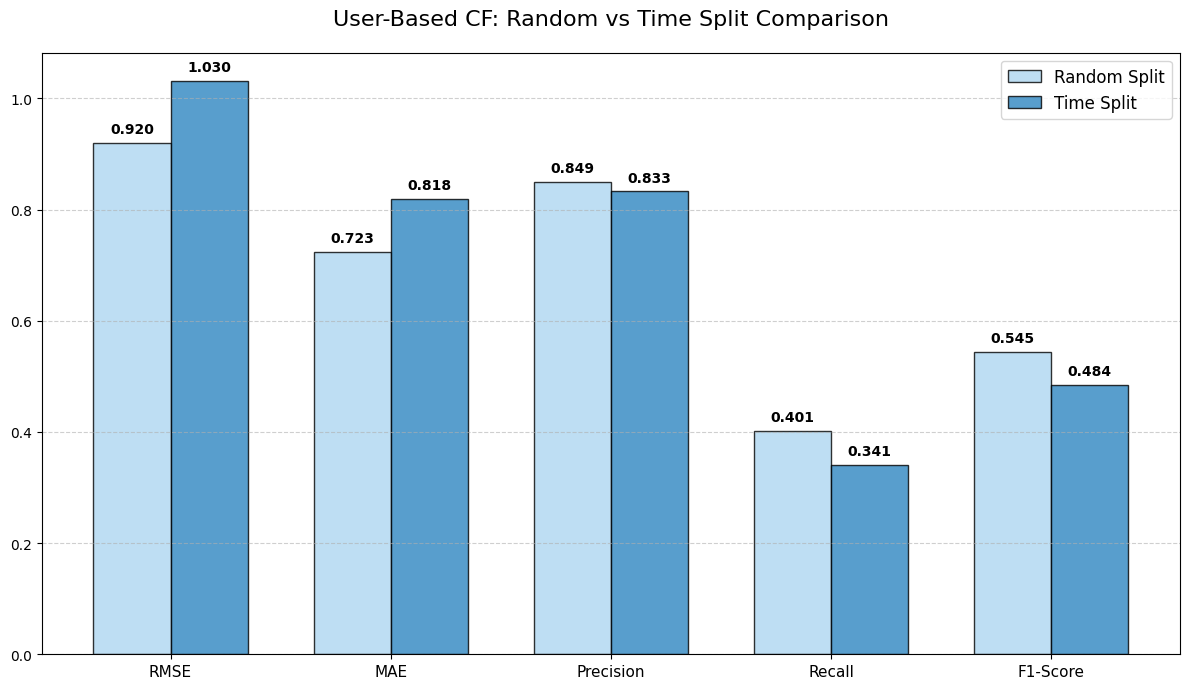


Metric     | Random   | Time     | Difference
--------------------------------------------------
RMSE       | 0.9196 | 1.0305 | +0.1109
MAE        | 0.7234 | 0.8185 | +0.0951
Precision  | 0.8489 | 0.8325 | -0.0164
Recall     | 0.4009 | 0.3408 | -0.0602
F1         | 0.5446 | 0.4836 | -0.0610


In [5]:
metrics = ['RMSE', 'MAE', 'Precision', 'Recall', 'F1']
display_names = ['RMSE', 'MAE', 'Precision', 'Recall', 'F1-Score']

random_data = [user_based_results['Random Split'][m] for m in metrics]
time_data = [user_based_results['Time Split'][m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

rects1 = ax.bar(x - width/2, random_data, width, label='Random Split', color='#AED6F1', edgecolor='black', alpha=0.8)
rects2 = ax.bar(x + width/2, time_data, width, label='Time Split', color='#2E86C1', edgecolor='black', alpha=0.8)

ax.set_title('User-Based CF: Random vs Time Split Comparison', fontsize=16, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(display_names, fontsize=11)
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.6)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print(f"{'Metric':<10} | {'Random':<8} | {'Time':<8} | {'Difference'}")
print("-" * 50)
for i, m in enumerate(metrics):
    diff = time_data[i] - random_data[i]
    print(f"{m:<10} | {random_data[i]:.4f} | {time_data[i]:.4f} | {diff:+.4f}")
print("="*50)

# 아이템 기반

In [6]:
class DampedKNNRecommender:
    def __init__(self, k=20, damping_factor=10, mode='user'):
        self.k = k
        self.damping = damping_factor
        self.mode = mode
        self.mu = 0
        self.bu = None
        self.bi = None
        self.sim_matrix = None
        self.res_matrix = None

    def fit(self, train_df):
        # 1. Baseline 계산
        self.mu = train_df['rating'].mean()

        # Item Bias (bi)
        i_group = train_df.groupby('movie_id')['rating']
        self.bi = (i_group.sum() - i_group.count() * self.mu) / (i_group.count() + self.damping)

        # User Bias (bu)
        temp_df = train_df.copy()
        # bi.get에서 값이 없는 경우 0 처리
        temp_df['tmp'] = temp_df.apply(lambda x: x['rating'] - self.mu - self.bi.get(x['movie_id'], 0), axis=1)
        u_group = temp_df.groupby('user_id')['tmp']
        self.bu = u_group.sum() / (u_group.count() + self.damping)

        # 2. 잔차 행렬 생성 (R - Baseline)
        temp_df['res'] = temp_df.apply(lambda x: x['rating'] - (self.mu + self.bu.get(x['user_id'], 0) + self.bi.get(x['movie_id'], 0)), axis=1)
        self.res_matrix = temp_df.pivot(index='user_id', columns='movie_id', values='res').fillna(0)

        # 3. 유사도 계산
        if self.mode == 'user':
            self.sim_matrix = pd.DataFrame(cosine_similarity(self.res_matrix),
                                          index=self.res_matrix.index, columns=self.res_matrix.index)
        else:
            # 아이템 기반: 영화 간 유사도
            self.sim_matrix = pd.DataFrame(cosine_similarity(self.res_matrix.T),
                                          index=self.res_matrix.columns, columns=self.res_matrix.columns)

    def predict(self, u_id, m_id):
        bu = self.bu.get(u_id, 0)
        bi = self.bi.get(m_id, 0)
        baseline = self.mu + bu + bi

        if self.mode == 'user':
            if u_id not in self.sim_matrix.index or m_id not in self.res_matrix.columns:
                return baseline
            others = self.res_matrix.loc[:, m_id]
            # 해당 영화를 본 유저들과의 유사도 추출
            valid_users = others[others != 0].index
            sim_scores = self.sim_matrix.loc[u_id, valid_users].sort_values(ascending=False)[:self.k]
            target_data = others # 전체 유저의 해당 영화 잔차
        else:
            if m_id not in self.sim_matrix.index or u_id not in self.res_matrix.index:
                return baseline
            watched = self.res_matrix.loc[u_id, :]
            # 해당 유저가 본 영화들과의 유사도 추출
            valid_movies = watched[watched != 0].index
            sim_scores = self.sim_matrix.loc[m_id, valid_movies].sort_values(ascending=False)[:self.k]
            target_data = watched # 해당 유저의 전체 영화 잔차

        # 수정: 유사도의 합이 0이면 분모 에러가 나므로 절대값 합으로 체크
        if np.abs(sim_scores).sum() < 1e-9:
            return baseline

        # 가중 평균 잔차 계산
        res_pred = np.dot(sim_scores, target_data[sim_scores.index]) / np.abs(sim_scores).sum()
        return baseline + res_pred

In [7]:
# 아이템 기반 실험 결과를 저장할 딕셔너리
item_based_results = {}

for name, train_set, val_set in [("Random Split", train_random, val_random), ("Time Split", train_time, val_time)]:
    print(f"\n[{name}] 아이템 기반 실험 시작...")
    best_rmse = float('inf')

    # 아이템 기반은 보통 사용자 기반보다 약간 더 큰 K에서 안정적인 경우가 많습니다.
    for k in [10, 20, 30, 40, 50]:
        # mode를 'item'으로 설정하는 것이 핵심입니다!
        model = DampedKNNRecommender(k=k, damping_factor=10, mode='item')
        model.fit(train_set)

        # 검증셋 예측
        preds = val_set.apply(lambda x: model.predict(x['user_id'], x['movie_id']), axis=1)
        preds = np.array(preds)
        actual = val_set['rating'].values

        # 지표 계산
        rmse = np.sqrt(mean_squared_error(actual, preds))
        mae = mean_absolute_error(actual, preds)

        # F1-Score 계산 (4.0점 기준)
        threshold = 4.0
        actual_rel = actual >= threshold
        pred_rel = preds >= threshold
        tp = np.sum(actual_rel & pred_rel)
        precision = tp / np.sum(pred_rel) if np.sum(pred_rel) > 0 else 0
        recall = tp / np.sum(actual_rel) if np.sum(actual_rel) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        print(f"K={k} -> RMSE: {rmse:.4f}, F1: {f1:.4f}")

        if rmse < best_rmse:
            best_rmse = rmse
            item_based_results[name] = {
                "K": k, "RMSE": rmse, "MAE": mae,
                "Precision": precision, "Recall": recall, "F1": f1
            }

# 아이템 기반 결과 요약 출력
print("\n" + "="*80)
print(f"{'검증 방식':<15} | {'Best K':<6} | {'RMSE':<7} | {'MAE':<7} | {'Prec.':<7} | {'Recall':<7} | {'F1':<7}")
print("-" * 80)
for name, res in item_based_results.items():
    print(f"{name:<15} | {res['K']:<6} | {res['RMSE']:.4f} | {res['MAE']:.4f} | {res['Precision']:.4f} | {res['Recall']:.4f} | {res['F1']:.4f}")
print("="*80)


[Random Split] 아이템 기반 실험 시작...
K=10 -> RMSE: 0.9168, F1: 0.5608
K=20 -> RMSE: 0.9090, F1: 0.5479
K=30 -> RMSE: 0.9088, F1: 0.5389
K=40 -> RMSE: 0.9098, F1: 0.5325
K=50 -> RMSE: 0.9107, F1: 0.5291

[Time Split] 아이템 기반 실험 시작...
K=10 -> RMSE: 1.0413, F1: 0.5116
K=20 -> RMSE: 1.0330, F1: 0.4988
K=30 -> RMSE: 1.0318, F1: 0.4938
K=40 -> RMSE: 1.0318, F1: 0.4896
K=50 -> RMSE: 1.0332, F1: 0.4881

검증 방식           | Best K | RMSE    | MAE     | Prec.   | Recall  | F1     
--------------------------------------------------------------------------------
Random Split    | 30     | 0.9088 | 0.7131 | 0.8645 | 0.3915 | 0.5389
Time Split      | 30     | 1.0318 | 0.8155 | 0.8276 | 0.3519 | 0.4938


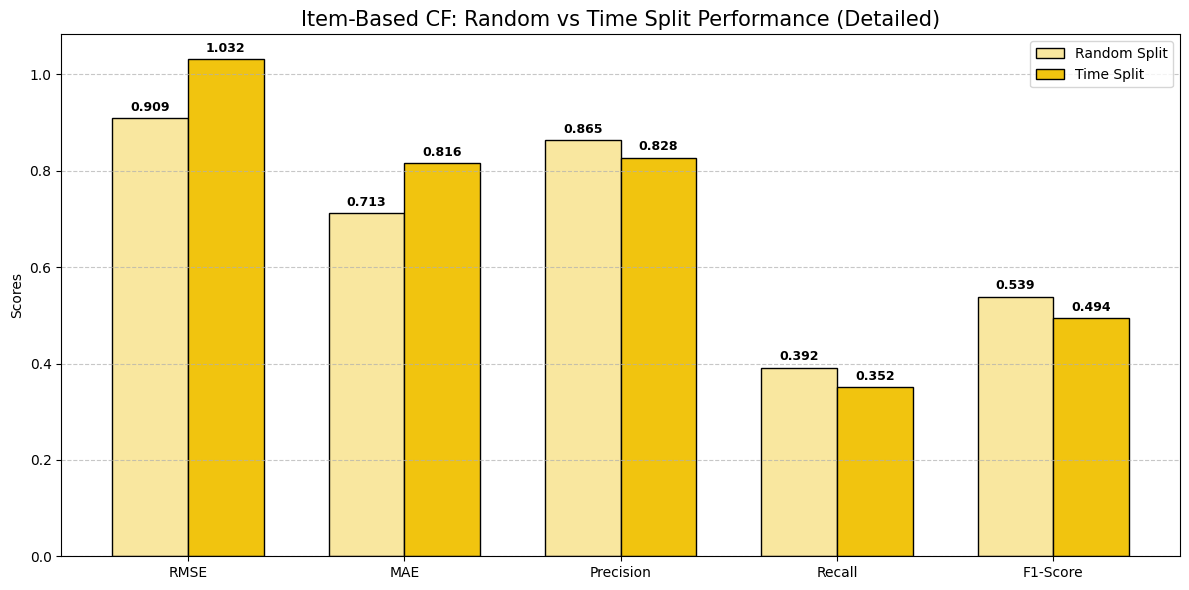


Metric          | Random Split    | Time Split      | Gap
-----------------------------------------------------------------
RMSE            | 0.9088          | 1.0318          | +0.1230
MAE             | 0.7131          | 0.8155          | +0.1024
Precision       | 0.8645          | 0.8276          | -0.0370
Recall          | 0.3915          | 0.3519          | -0.0396
F1-Score        | 0.5389          | 0.4938          | -0.0451


In [8]:
# 1. 데이터 정리 (항목을 5개로 확장)
categories = ['RMSE', 'MAE', 'Precision', 'Recall', 'F1-Score'] # Precision, Recall 추가
metrics_keys = ['RMSE', 'MAE', 'Precision', 'Recall', 'F1']    # 딕셔너리 키 이름

try:
    # 딕셔너리에서 데이터를 가져올 때 확장된 metrics_keys 사용
    item_random_vals = [item_based_results['Random Split'][k] for k in metrics_keys]
    item_time_vals = [item_based_results['Time Split'][k] for k in metrics_keys]
except KeyError as e:
    print(f"오류: {e} 결과가 없습니다. 실험 루프에서 해당 지표가 저장되었는지 확인해주세요.")
else:
    # 2. 그래프 설정
    x = np.arange(len(categories))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6)) # 가로 길이를 조금 늘려 지표 5개가 잘 보이게 함
    rects1 = ax.bar(x - width/2, item_random_vals, width, label='Random Split', color='#F9E79F', edgecolor='black')
    rects2 = ax.bar(x + width/2, item_time_vals, width, label='Time Split', color='#F1C40F', edgecolor='black')

    # 스타일링
    ax.set_ylabel('Scores')
    ax.set_title('Item-Based CF: Random vs Time Split Performance (Detailed)', fontsize=15)
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()

    # 수치 표시 함수 (기존과 동일)
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 3. 요약 표 출력
    print("\n" + "="*65)
    print(f"{'Metric':<15} | {'Random Split':<15} | {'Time Split':<15} | {'Gap'}")
    print("-" * 65)
    for i, cat in enumerate(categories):
        gap = item_time_vals[i] - item_random_vals[i]
        print(f"{cat:<15} | {item_random_vals[i]:<15.4f} | {item_time_vals[i]:<15.4f} | {gap:+.4f}")
    print("="*65)

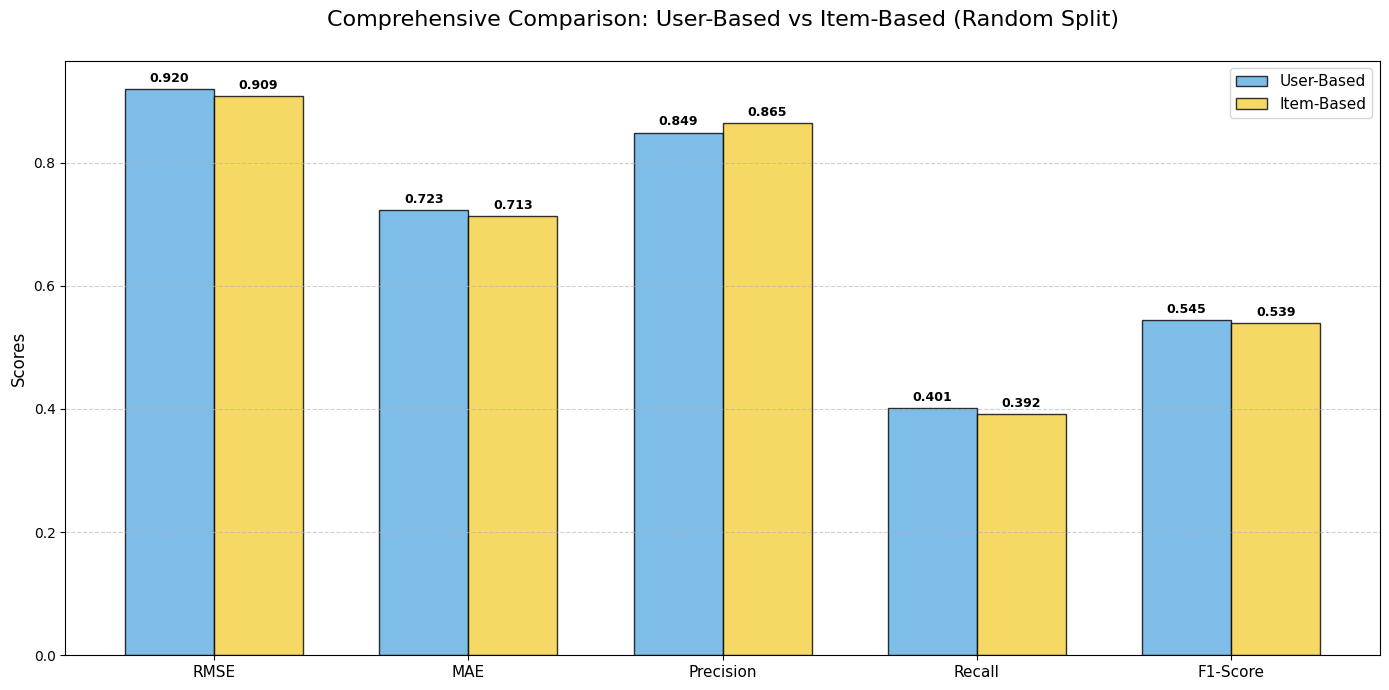


Metric          | User-Based   | Item-Based   | Winner
--------------------------------------------------------------------------------
RMSE            | 0.9196       | 0.9088       | Item
MAE             | 0.7234       | 0.7131       | Item
Precision       | 0.8489       | 0.8645       | Item
Recall          | 0.4009       | 0.3915       | User
F1-Score        | 0.5446       | 0.5389       | User


In [9]:
# 1. 5개 지표 모두 추출 (Precision, Recall 추가)
labels = ['RMSE', 'MAE', 'Precision', 'Recall', 'F1-Score']
metrics_keys = ['RMSE', 'MAE', 'Precision', 'Recall', 'F1'] # 딕셔너리 접근 키

# 사용자 기반 Random 결과
user_random = [user_based_results['Random Split'][k] for k in metrics_keys]

# 아이템 기반 Random 결과
item_random = [item_based_results['Random Split'][k] for k in metrics_keys]

# 2. 그래프 그리기
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 7)) # 지표가 늘어났으므로 가로 폭을 더 넓힘

rects1 = ax.bar(x - width/2, user_random, width, label='User-Based', color='#5DADE2', edgecolor='black', alpha=0.8)
rects2 = ax.bar(x + width/2, item_random, width, label='Item-Based', color='#F4D03F', edgecolor='black', alpha=0.8)

# 스타일링
ax.set_ylabel('Scores', fontsize=12)
ax.set_title('Comprehensive Comparison: User-Based vs Item-Based (Random Split)', fontsize=16, pad=25)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=11)

# 수치 표시 (기존 autolabel 함수 활용)
autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 3. 요약 표 출력 (판단 로직 업데이트)
print("\n" + "="*80)
print(f"{'Metric':<15} | {'User-Based':<12} | {'Item-Based':<12} | {'Winner'}")
print("-" * 80)
for i, cat in enumerate(labels):
    u_val = user_random[i]
    i_val = item_random[i]

    # RMSE, MAE는 낮은 게 좋고, Precision, Recall, F1은 높은 게 좋음
    if cat in ['RMSE', 'MAE']:
        winner = 'Item' if i_val < u_val else 'User'
    else:
        winner = 'Item' if i_val > u_val else 'User'

    print(f"{cat:<15} | {u_val:<12.4f} | {i_val:<12.4f} | {winner}")
print("="*80)

# 카츠척도

In [10]:
class KatzFinalModel:
    def __init__(self, beta=0.1, top_k=30):
        self.beta = beta
        self.top_k = top_k
        self.mu = 0
        self.bu = None
        self.bi = None
        self.katz_sim = None
        self.res_matrix = None

    def fit(self, train_df):
        # 1. Baseline (편향) 계산
        self.mu = train_df['rating'].mean()
        self.bi = train_df.groupby('movie_id')['rating'].mean() - self.mu
        temp_df = train_df.copy()
        temp_df['res_i'] = temp_df['rating'] - self.mu - temp_df['movie_id'].map(self.bi).fillna(0)
        self.bu = temp_df.groupby('user_id')['res_i'].mean()

        # 2. 잔차 행렬 생성
        temp_df['res'] = temp_df['rating'] - (self.mu + temp_df['user_id'].map(self.bu).fillna(0) + temp_df['movie_id'].map(self.bi).fillna(0))
        self.res_matrix = temp_df.pivot(index='user_id', columns='movie_id', values='res').fillna(0)

        # 3. Katz 유사도 계산 (A*A.T 기반 2-hop)
        A = (self.res_matrix != 0).astype(float).values
        user_user_paths = np.dot(A, A.T)
        K = (self.beta**2) * user_user_paths

        self.katz_sim = pd.DataFrame(K, index=self.res_matrix.index, columns=self.res_matrix.index)
        np.fill_diagonal(self.katz_sim.values, 0)

    def predict(self, u_id, m_id):
        bu = self.bu.get(u_id, 0)
        bi = self.bi.get(m_id, 0)
        baseline = self.mu + bu + bi

        if u_id not in self.katz_sim.index or m_id not in self.res_matrix.columns:
            return baseline

        sim_scores = self.katz_sim.loc[u_id]
        item_res = self.res_matrix.loc[:, m_id]
        voted_idx = item_res[item_res != 0].index

        # Top-K 필터링
        target_sims = sim_scores[voted_idx].sort_values(ascending=False).head(self.top_k)

        if target_sims.sum() == 0:
            return baseline

        pred_res = np.dot(target_sims, item_res[target_sims.index]) / np.abs(target_sims).sum()
        return max(1, min(5, baseline + pred_res))

# ---------------------------------------------------------
# 1. 파라미터 그리드 서치 (최적의 조합 찾기)
# ---------------------------------------------------------
beta_candidates = [0.01, 0.05, 0.1, 0.15, 0.2] # 베타 후보군 다양화
k_candidates = [10, 20, 30, 50, 100]           # K 후보군 다양화

best_rmse = float('inf')
best_params = {'beta': 0, 'k': 0}

print("=== [Step 1] 하이퍼파라미터 최적화 시작 ===")
# 속도를 위해 Random Split의 일부 데이터(2000건)로만 튜닝 진행
sample_val = val_random.sample(2000, random_state=42)

for b in beta_candidates:
    for k in k_candidates:
        model = KatzFinalModel(beta=b, top_k=k)
        model.fit(train_random)

        preds = sample_val.apply(lambda x: model.predict(x['user_id'], x['movie_id']), axis=1)
        rmse = np.sqrt(mean_squared_error(sample_val['rating'], preds))

        print(f"Testing -> Beta: {b:<5} | K: {k:<3} | RMSE: {rmse:.4f}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_params['beta'] = b
            best_params['k'] = k

print(f"\n✅ 최적 조합 발견: Beta={best_params['beta']}, K={best_params['k']} (RMSE: {best_rmse:.4f})")

# ---------------------------------------------------------
# 2. 최적의 파라미터로 최종 평가 (Random vs Time)
# ---------------------------------------------------------
print("\n=== [Step 2] 최적 파라미터 기반 최종 평가 시작 ===")
final_katz_results = {}

for name, train_set, val_set in [("Random Split", train_random, val_random), ("Time Split", train_time, val_time)]:
    model = KatzFinalModel(beta=best_params['beta'], top_k=best_params['k'])
    model.fit(train_set)

    preds = val_set.apply(lambda x: model.predict(x['user_id'], x['movie_id']), axis=1)
    actual = val_set['rating'].values

    # 1. 오차 지표
    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae = mean_absolute_error(actual, preds)

    # 2. 랭킹 지표 계산 (4.0점 기준)
    thresh = 4.0
    actual_rel = actual >= thresh
    pred_rel = preds >= thresh

    tp = np.sum(actual_rel & pred_rel)
    prec = tp / np.sum(pred_rel) if np.sum(pred_rel) > 0 else 0
    rec = tp / np.sum(actual_rel) if np.sum(actual_rel) > 0 else 0
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

    # [수정] 모든 지표를 딕셔너리에 저장
    final_katz_results[name] = {
        "RMSE": rmse,
        "MAE": mae,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    }
    print(f"[{name}] 완료!")

# ---------------------------------------------------------
# 3. 최종 결과 출력 (Precision, Recall 컬럼 추가)
# ---------------------------------------------------------
print("\n" + "="*80)
print(f"{'Data Split':<15} | {'RMSE':<7} | {'MAE':<7} | {'Prec.':<7} | {'Recall':<7} | {'F1':<7}")
print("-" * 80)
for name, res in final_katz_results.items():
    print(f"{name:<15} | {res['RMSE']:.4f} | {res['MAE']:.4f} | {res['Precision']:.4f} | {res['Recall']:.4f} | {res['F1']:.4f}")
print("="*80)

=== [Step 1] 하이퍼파라미터 최적화 시작 ===
Testing -> Beta: 0.01  | K: 10  | RMSE: 0.9772
Testing -> Beta: 0.01  | K: 20  | RMSE: 0.9584
Testing -> Beta: 0.01  | K: 30  | RMSE: 0.9546
Testing -> Beta: 0.01  | K: 50  | RMSE: 0.9513
Testing -> Beta: 0.01  | K: 100 | RMSE: 0.9527
Testing -> Beta: 0.05  | K: 10  | RMSE: 0.9772
Testing -> Beta: 0.05  | K: 20  | RMSE: 0.9584
Testing -> Beta: 0.05  | K: 30  | RMSE: 0.9546
Testing -> Beta: 0.05  | K: 50  | RMSE: 0.9513
Testing -> Beta: 0.05  | K: 100 | RMSE: 0.9527
Testing -> Beta: 0.1   | K: 10  | RMSE: 0.9772
Testing -> Beta: 0.1   | K: 20  | RMSE: 0.9584
Testing -> Beta: 0.1   | K: 30  | RMSE: 0.9546
Testing -> Beta: 0.1   | K: 50  | RMSE: 0.9513
Testing -> Beta: 0.1   | K: 100 | RMSE: 0.9527
Testing -> Beta: 0.15  | K: 10  | RMSE: 0.9772
Testing -> Beta: 0.15  | K: 20  | RMSE: 0.9584
Testing -> Beta: 0.15  | K: 30  | RMSE: 0.9546
Testing -> Beta: 0.15  | K: 50  | RMSE: 0.9513
Testing -> Beta: 0.15  | K: 100 | RMSE: 0.9527
Testing -> Beta: 0.2   | K: 

In [11]:
results = {
        'User-Based': user_based_results,
        'Item-Based': item_based_results,
        'Katz-Graph': final_katz_results
    }

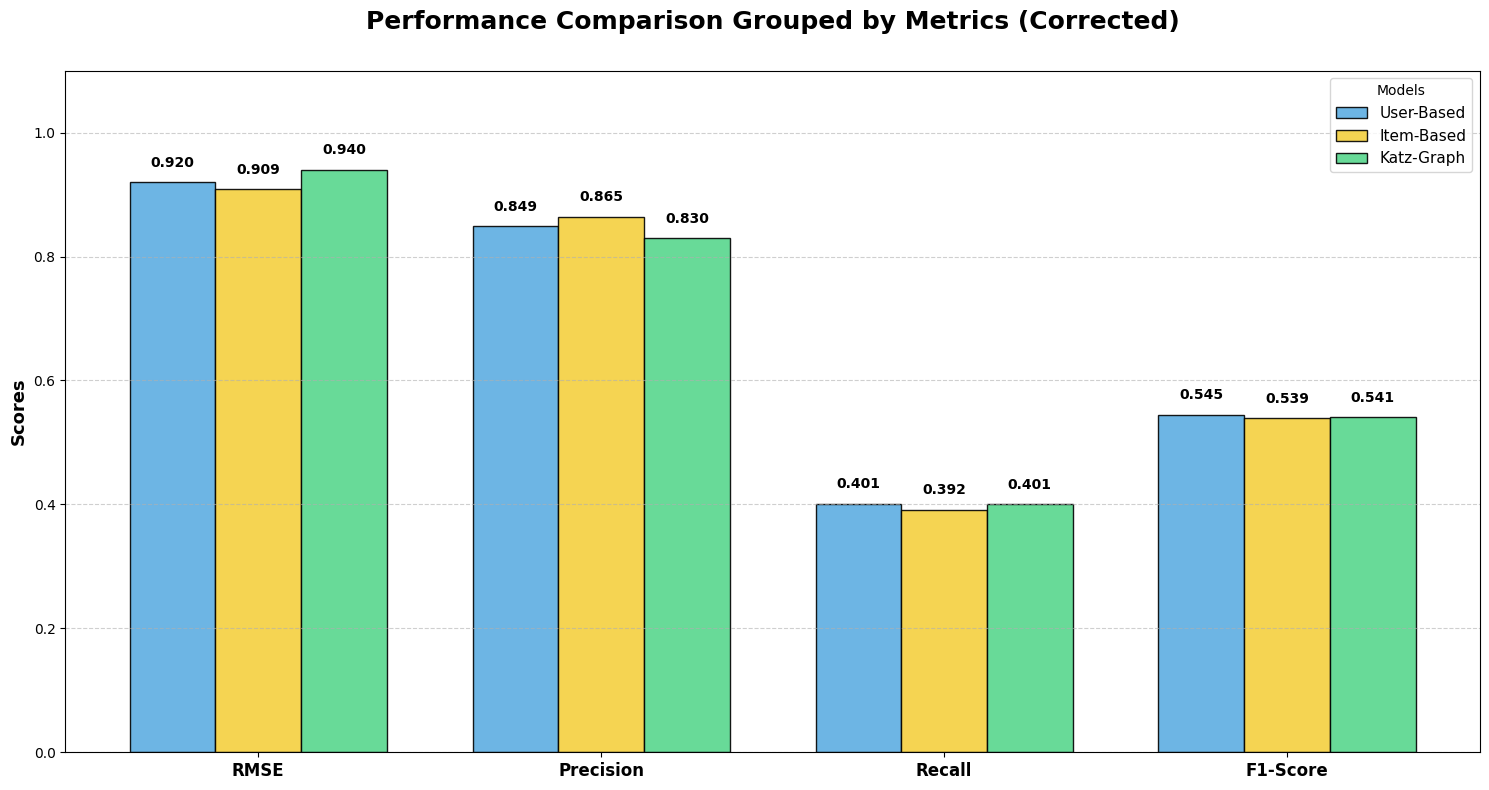

In [12]:
# 1. 데이터 확인 및 정리 (정확한 수치 바인딩)
models = ['User-Based', 'Item-Based', 'Katz-Graph']
metrics = ['RMSE', 'Precision', 'Recall', 'F1-Score']

# 딕셔너리에서 정확한 값을 리스트로 추출
# (results 변수에 데이터가 올바르게 들어있다고 가정합니다)
data = {
    'RMSE': [results['User-Based']['Random Split']['RMSE'],
             results['Item-Based']['Random Split']['RMSE'],
             results['Katz-Graph']['Random Split']['RMSE']],
    'Precision': [results['User-Based']['Random Split']['Precision'],
                  results['Item-Based']['Random Split']['Precision'],
                  results['Katz-Graph']['Random Split']['Precision']],
    'Recall': [results['User-Based']['Random Split']['Recall'],
               results['Item-Based']['Random Split']['Recall'],
               results['Katz-Graph']['Random Split']['Recall']],
    'F1-Score': [results['User-Based']['Random Split']['F1'],
                 results['Item-Based']['Random Split']['F1'],
                 results['Katz-Graph']['Random Split']['F1']]
}

# 2. 그래프 설정
x = np.arange(len(metrics))  # 지표 개수 (4개)
width = 0.25  # 모델별 막대 너비

fig, ax = plt.subplots(figsize=(15, 8))

# 모델별 색상 설정
colors = ['#5DADE2', '#F4D03F', '#58D68D'] # User, Item, Katz 순서

# 3. 모델별로 막대 그리기
for i, model_name in enumerate(models):
    # 각 지표에 대해 해당 모델의 점수들을 가져옴
    model_scores = [data[m][i] for m in metrics]
    ax.bar(x + (i - 1) * width, model_scores, width, label=model_name,
           color=colors[i], edgecolor='black', alpha=0.9)

# 4. 스타일링 및 축 설정
ax.set_title('Performance Comparison Grouped by Metrics (Corrected)', fontsize=18, fontweight='bold', pad=30)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.set_ylabel('Scores', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)  # 모든 지표가 0~1 사이이므로 1.1까지 설정

# 5. 수치 라벨링 (막대 위에 숫자 표시)
for i in range(len(models)):
    for j in range(len(metrics)):
        val = data[metrics[j]][i]
        ax.text(j + (i - 1) * width, val + 0.02, f'{val:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# 그리드 및 범례
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.legend(title="Models", loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

예측값의 수치적 정확도(RMSE)와 정밀도(Precision) 측면에서는 Item-Based CF가 가장 우수한 성능을 보였다. 반면 사용자의 선호 아이템을 폭넓게 찾아내는 능력(Recall)과 종합적인 추천 밸런스(F1-Score) 측면에서는 User-Based CF가 뛰어난 결과.

이는 안정적인 평점 패턴을 가진 아이템 기반 방식이 개별 평점 예측에는 유리, 유저의 다양한 취향을 반영하는 데는 사용자 간 유사도를 활용하는 방식이 더 효과적임

## 모델저장

In [13]:
# 현재 results 딕셔너리에 담긴 수치 확인
print("--- [현재 실험 결과 요약] ---")
for model_name in ['User-Based', 'Item-Based', 'Katz-Graph']:
    res = results[model_name]['Random Split']
    print(f"[{model_name}] RMSE: {res['RMSE']:.4f} | F1: {res['F1']:.4f}")

# 만약 루프를 돌면서 'best_params' 같은 변수를 만드셨다면 아래처럼 확인 가능합니다.
# print(f"최적의 User K: {best_params_user['k']}")

--- [현재 실험 결과 요약] ---
[User-Based] RMSE: 0.9196 | F1: 0.5446
[Item-Based] RMSE: 0.9088 | F1: 0.5389
[Katz-Graph] RMSE: 0.9405 | F1: 0.5405


In [16]:
import pickle

print("--- [최적 모델 최종 학습 및 저장 시작] ---")

# (1) User-Based: Best K=40
best_user_model = DampedKNNRecommender(k=40, mode='user')
best_user_model.fit(train_random)
print("✅ User-Based (K=40) 학습 완료")

# (2) Item-Based: Best K=30
best_item_model = DampedKNNRecommender(k=30, mode='item')
best_item_model.fit(train_random)
print("✅ Item-Based (K=30) 학습 완료")

# (3) Katz-Graph: Beta=0.01, K=50
best_katz_model = KatzFinalModel(beta=0.01, top_k=50)
best_katz_model.fit(train_random)
print("✅ Katz-Graph (Beta=0.01, K=50) 학습 완료")

model_package = {
    'user_based': best_user_model,
    'item_based': best_item_model,
    'katz_graph': best_katz_model,
    'params': {
        'user_k': 40,
        'item_k': 30,
        'katz_beta': 0.01,
        'katz_k': 50
    }
}

with open('final_best_models.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print("\n모든 최적 모델이 'final_best_models.pkl' 파일에 저장")

--- [최적 모델 최종 학습 및 저장 시작] ---
✅ User-Based (K=40) 학습 완료
✅ Item-Based (K=30) 학습 완료
✅ Katz-Graph (Beta=0.01, K=50) 학습 완료

모든 최적 모델이 'final_best_models.pkl' 파일에 저장


In [20]:
import os

# 파일명을 변수에 담습니다.
filename = 'final_best_models.pkl'

# if 문을 사용하여 존재 여부를 체크합니다.
if os.path.exists(filename):
    print(f"✅ [확인 완료] '{filename}' 파일이 현재 폴더에 존재합니다!")
    print(f"📍 전체 절대 경로: {os.path.abspath(filename)}")
else:
    print(f"❌ [경고] '{filename}' 파일을 찾을 수 없습니다.")
    print("현재 폴더에 있는 파일 목록:")
    print(os.listdir()) # 실제로 어떤 파일들이 있는지 목록을 보여줍니다.

✅ [확인 완료] 'final_best_models.pkl' 파일이 현재 폴더에 존재합니다!
📍 전체 절대 경로: /content/final_best_models.pkl
